In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from keras import layers
from keras.models import Model,load_model
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Bidirectional,Dropout,LeakyReLU
from tensorflow.keras.optimizers import Nadam
from matplotlib import pyplot as plt

In [ ]:
load_df = pd.read_csv('drive/MyDrive/python/lstm/My_data.csv')
df_Date_Time = load_df [['Date','Time']]
duplicate_indices = df_Date_Time[df_Date_Time.duplicated()].index
df = pd.DataFrame(load_df.drop(duplicate_indices-1))
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['minutes_since_midnight'] = df['datetime'].dt.hour * 60 + df['datetime'].dt.minute
df.head(-1)

,Date,Time,Open,High,Low,Close,Volume,MA,datetime,minutes_since_midnight
0,2023.09.22,09:58,34394,34395,34392,34392,32,34392.000000,2023-09-22 09:58:00,598
1,2023.09.22,09:59,34391,34394,34381,34381,41,34390.952381,2023-09-22 09:59:00,599
2,2023.09.22,10:00,34379,34379,34348,34350,120,34387.052154,2023-09-22 10:00:00,600
3,2023.09.22,10:01,34351,34352,34341,34346,110,34383.142425,2023-09-22 10:01:00,601
4,2023.09.22,10:02,34345,34357,34345,34354,80,34380.366956,2023-09-22 10:02:00,602
...,...,...,...,...,...,...,...,...,...,...
64995,2023.11.28,21:16,35427,35435,35425,35425,45,35425.429434,2023-11-28 21:16:00,1276
64996,2023.11.28,21:17,35426,35430,35424,35425,41,35425.388535,2023-11-28 21:17:00,1277
64997,2023.11.28,21:18,35424,35430,35423,35424,40,35425.256294,2023-11-28 21:18:00,1278
64998,2023.11.28,21:19,35422,35425,35418,35425,53,35425.231885,2023-11-28 21:19:00,1279


In [ ]:
scaler = MinMaxScaler()
df['scaled_time'] = scaler.fit_transform(df[['minutes_since_midnight']])
df['scaled_time'] =-1+(df['scaled_time']*(2))
df = df.drop(['datetime', 'minutes_since_midnight'], axis=1)
last_row = df.iloc[-1].copy()

In [ ]:
df['target_c']=df.Close.shift(periods=-1)
df['target_h']=df.High.shift(periods=-1)
df['target_l']=df.Low.shift(periods=-1)
df = df.drop(df.index[-1])
time_feature=df['scaled_time']
print(df['scaled_time'].max())
df.head(-1)

1.0


,Date,Time,Open,High,Low,Close,Volume,MA,scaled_time,target_c,target_h,target_l
0,2023.09.22,09:58,34394,34395,34392,34392,32,34392.000000,-0.168289,34381.0,34394.0,34381.0
1,2023.09.22,09:59,34391,34394,34381,34381,41,34390.952381,-0.166898,34350.0,34379.0,34348.0
2,2023.09.22,10:00,34379,34379,34348,34350,120,34387.052154,-0.165508,34346.0,34352.0,34341.0
3,2023.09.22,10:01,34351,34352,34341,34346,110,34383.142425,-0.164117,34354.0,34357.0,34345.0
4,2023.09.22,10:02,34345,34357,34345,34354,80,34380.366956,-0.162726,34355.0,34361.0,34352.0
...,...,...,...,...,...,...,...,...,...,...,...,...
64994,2023.11.28,21:15,35423,35429,35420,35426,48,35425.474637,0.773296,35425.0,35435.0,35425.0
64995,2023.11.28,21:16,35427,35435,35425,35425,45,35425.429434,0.774687,35425.0,35430.0,35424.0
64996,2023.11.28,21:17,35426,35430,35424,35425,41,35425.388535,0.776078,35424.0,35430.0,35423.0
64997,2023.11.28,21:18,35424,35430,35423,35424,40,35425.256294,0.777469,35425.0,35425.0,35418.0


In [ ]:
# Assuming 'feature1' through 'feature5' are the features to standardize
features_to_standardize = df[['Open', 'High', 'Low', 'Close', 'Volume','MA']].values

# Standardize features using StandardScaler
scaler_features = StandardScaler()
features_standardized = scaler_features.fit_transform(features_to_standardize)

# Standardize targets using StandardScaler
target_c_to_standardize = df[['target_c']].values
scaler_target_c=StandardScaler()
y_c =scaler_target_c.fit_transform(target_c_to_standardize)

# Combine the standardized features and the scaled time back into a DataFrame
df_standardized = pd.DataFrame(features_standardized, columns=['Open', 'High', 'Low', 'Close', 'Volume','MA'])
df_standardized['time'] = time_feature
# Extract features
X = df_standardized[['Open', 'High', 'Low', 'Close', 'Volume','time','MA']].values


In [ ]:
y_c.shape

(65000, 1)

In [ ]:
time_steps = 60
# Function to create sequences with the specified lookback window
def create_sequences(data, time_steps):
    sequences = []
    for i in range(len(data) - time_steps):
        sequence = data[i:i + time_steps, :]
        sequences.append(sequence)
    return np.array(sequences)

# Reshape the data to create sequences
X_reshaped = create_sequences(X, time_steps)
#X_test_reshaped = create_sequences(X_test, time_steps)

# Reshape the target data to align with the reshaped input data
y_reshaped = y_c[time_steps:]
#y_test_reshaped = y_test[time_steps:]

# Display the reshaped shapes
print("X_reshaped shape:", X_reshaped.shape)
#print("X_test_reshaped shape:", X_test_reshaped.shape)
print("y_reshaped shape:", y_reshaped.shape)
#print("y_test_reshaped shape:", y_test_reshaped.shape)

X_reshaped shape: (64940, 60, 7)
y_reshaped shape: (64940, 1)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_reshaped, y_reshaped, test_size=0.02, shuffle=False)
print(f"X_train shape:{X_train.shape}")
print(f"Y_train shape:{Y_train.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"Y_test shape:{Y_test.shape}")
num_features=X_train.shape[2]

X_train shape:(63641, 60, 7)
Y_train shape:(63641, 1)
X_test shape:(1299, 60, 7)
Y_test shape:(1299, 1)


In [ ]:
model = Sequential()
model.add(Bidirectional(LSTM(units = 512,return_sequences=True), input_shape = (time_steps,num_features)))
#model.add(Dropout(0.5))  # Adding Dropout after the Bidirectional LSTM layer
model.add(Bidirectional(LSTM(units = 512,activation='tanh')))
#model.add(Dropout(0.5))  # Adding Dropout after the Bidirectional LSTM layer
model.add(Dense(units = 1,activation='linear'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_8 (Bidirecti  (None, 60, 1024)          2129920   
 onal)                                                           
                                                                 
 bidirectional_9 (Bidirecti  (None, 512)               2623488   
 onal)                                                           
                                                                 
 dense_4 (Dense)             (None, 1)                 513       
                                                                 
Total params: 4753921 (18.13 MB)
Trainable params: 4753921 (18.13 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
num_epoch = 20
#optimizer = Nadam(learning_rate=0.001)  # Adjust the learning rate as needed
model.compile(optimizer='Nadam', loss='mse', metrics=['mae'])
history = model.fit(X_train,
                    Y_train,
                    batch_size=512,
                    epochs=num_epoch,
                    validation_split=0.1,
                    callbacks=[EarlyStopping(monitor='val_mae',min_delta=1e-3,patience=5, mode='min',restore_best_weights=True)])

Epoch 1/20
56/56 [==============================] - 46s 674ms/step - loss: 0.0259 - mae: 0.0562 - val_loss: 3.1599e-04 - val_mae: 0.0132
Epoch 2/20
56/56 [==============================] - 37s 664ms/step - loss: 0.0014 - mae: 0.0257 - val_loss: 0.0013 - val_mae: 0.0316
Epoch 3/20
56/56 [==============================] - 38s 677ms/step - loss: 6.3147e-04 - mae: 0.0167 - val_loss: 1.7303e-04 - val_mae: 0.0093
Epoch 4/20
56/56 [==============================] - 38s 683ms/step - loss: 9.7807e-04 - mae: 0.0202 - val_loss: 1.4972e-04 - val_mae: 0.0087
Epoch 5/20
56/56 [==============================] - 37s 670ms/step - loss: 0.0010 - mae: 0.0198 - val_loss: 0.0017 - val_mae: 0.0387
Epoch 6/20
56/56 [==============================] - 38s 670ms/step - loss: 4.4587e-04 - mae: 0.0138 - val_loss: 1.4746e-04 - val_mae: 0.0087
Epoch 7/20
56/56 [==============================] - 39s 689ms/step - loss: 5.0583e-04 - mae: 0.0152 - val_loss: 0.0052 - val_mae: 0.0706
Epoch 8/20
56/56 [===================

In [ ]:
# Evaluate the model on the test set
loss = model.evaluate(X_test, Y_test)
print(f'Test Loss: {loss}')

41/41 [==============================] - 1s 16ms/step - loss: 2.8269e-04 - mae: 0.0121
Test Loss: [0.0002826898416969925, 0.012076131999492645]


In [ ]:
model.save('drive/MyDrive/python/lstm/lstm_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load the model back
loaded_model = load_model('drive/MyDrive/python/lstm/lstm_model.h5')

In [ ]:
loss = loaded_model.evaluate(X_test, Y_test)
print(f'Test Loss: {loss}')

41/41 [==============================] - 3s 16ms/step - loss: 2.8269e-04 - mae: 0.0121
Test Loss: [0.0002826898416969925, 0.012076131999492645]


41/41 [==============================] - 2s 15ms/step


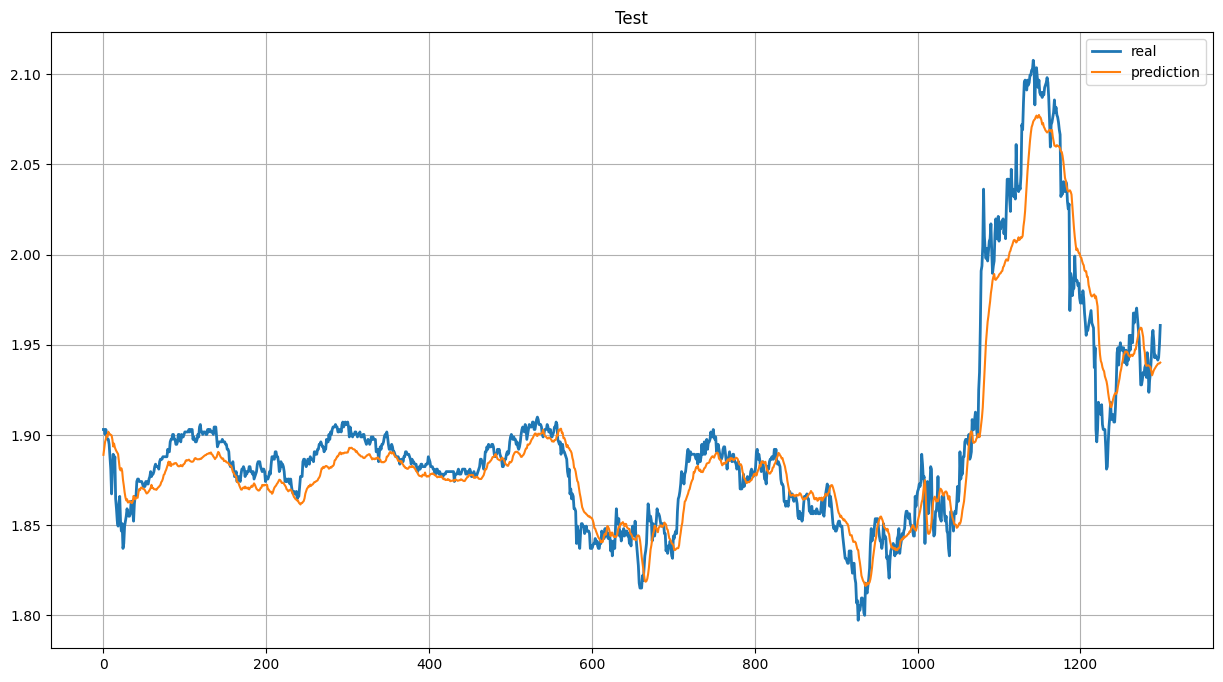

In [ ]:
# plot test close and prediction
Y_prediction = model.predict(X_test)
plt.figure(figsize=[15,8])
plt.plot(Y_test,linewidth=2)
plt.plot(Y_prediction)
plt.title("Test")
plt.legend(['real','prediction'])
plt.grid()
plt.show()

In [ ]:
Y_prediction.shape

(1299, 1)

In [ ]:
Y_prediction_orginal=scaler_target.inverse_transform(Y_prediction)
Y_test_orginal=scaler_target.inverse_transform(Y_test)

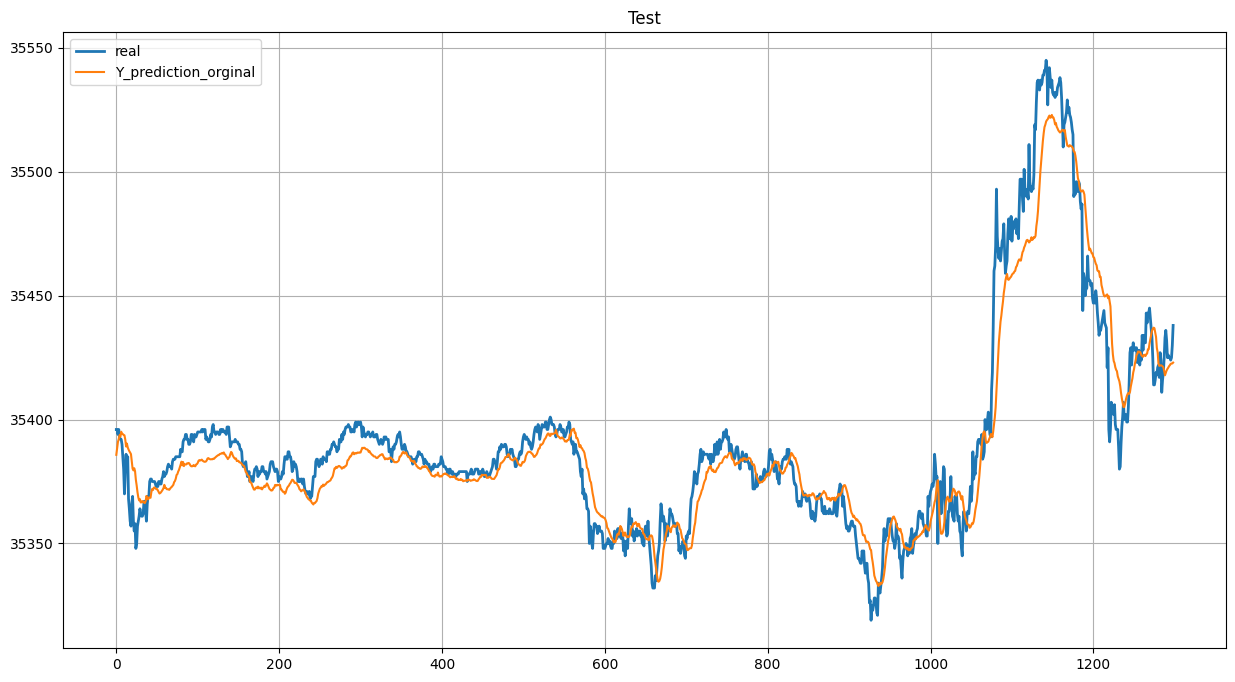

In [ ]:
# plot test close and prediction
plt.figure(figsize=[15,8])
plt.plot(Y_test_orginal,linewidth=2)
plt.plot(Y_prediction_orginal)
plt.title("Test")
plt.legend(['real','Y_prediction_orginal'])
plt.grid()
plt.show()